# Mapping Brand Perception with Correspondence Analysis (PROC CORRESP)

## Executive Summary

A market-research team fields a brand-by-attribute perception survey across four established streaming-media brands and uses **PROC CORRESP** to turn the resulting crosstab into a two-dimensional perceptual map. The brand x attribute association is strong and real: the chi-square test of independence is **800.31 on 15 degrees of freedom (p < 0.0001)**, with **Cramer's V = 0.3334**. Correspondence analysis compresses that association into two axes that together explain **100%** of the table's inertia — **60.8%** on Dimension 1 and **39.2%** on Dimension 2 — so the 2-D map is a complete, faithful summary.

The map separates a **premium-content** pole (CineNow, anchored on *Content_Depth* and *Original_Shows*) from a **trendy/casual** pole (PixelPlay near *Trendy* and *Easy_to_Use*) along Dimension 1, while Dimension 2 lifts a **value/reliability** cluster (Streamly and BingeBox near *Affordable* and *Reliable*) above those two distinctive-content brands. An emerging challenger, **NovaCast**, is then projected as a *supplementary* point — it does not influence the axes — and lands near the origin at (-0.1074, -0.1247), leaning slightly toward the Trendy / Easy_to_Use corner, i.e. an as-yet-undifferentiated newcomer drifting into PixelPlay's territory.

## Data Sources

| Dataset | Rows | Key Variables | Description |
|---------|------|---------------|-------------|
| `perception` | 2400 (400 respondents x 6 attributes) | `Brand` (char), `Attribute` (char) | Synthetic survey: each respondent names the streaming brand they most associate with each of six attributes. Brand affinities are encoded as `RAND("Table", ...)` category probabilities so the contingency table has realistic, non-uniform association. |
| `survey_counts` | 24 (4 brands x 6 attributes) | `Brand`, `Attribute`, `Count` | Pre-aggregated contingency cells from `perception` via PROC FREQ — the weighted input to the supplementary-point CA run. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | `OUTC=` coordinate datasets written by PROC CORRESP; the second adds the projected NovaCast point and drives the perceptual map. |

Established brands: **Streamly, PixelPlay, CineNow, BingeBox**; challenger **NovaCast** (projected as a supplementary point). Attributes: Affordable, Content_Depth, Easy_to_Use, Original_Shows, Reliable, Trendy. Seed `streaminit(20260531)` makes the data reproducible.

The 400-respondent survey resolves to a 4x6 contingency table totalling **2400** respondent-attribute associations, with strong, non-uniform association structure (chi-square = 800.31, p < 0.0001) that correspondence analysis recovers cleanly.

## What correspondence analysis does here

When a brand-tracking survey asks consumers which brand they most associate with each of several attributes, the result is a **brand x attribute contingency table**. The raw counts are hard to read: every brand is compared against every attribute, and the signal is the *pattern of association*, not the cell values.

Correspondence analysis (CA) decomposes the chi-square association of the table into a low-dimensional space, so brands and attributes that are associated land near each other on one map. In this notebook we:

1. Generate a synthetic perception survey for four streaming brands.
2. Inspect the raw contingency structure (and its chi-square) with `PROC FREQ`.
3. Run `PROC CORRESP` with full diagnostics and read the real inertia and coordinates.
4. Project an emerging challenger brand as a **supplementary** point.
5. Draw and interpret the resulting perceptual map.

## Step 1 — Generate the synthetic perception survey

We simulate survey respondents. For each respondent we ask, for each of six attributes, *which brand do you most associate with this attribute?* Each brand has a distinct **affinity profile** — a vector of category probabilities passed to `RAND("Table", ...)` — so that, for example, *PixelPlay* skews Trendy while *CineNow* skews toward Content_Depth and Original_Shows. This produces a contingency table with genuine, non-uniform association for CA to recover. The data are fully synthetic and reproducible via `CALL STREAMINIT`.

In [1]:
data perception;
    /* Reproducible synthetic brand-perception survey */
    call streaminit(20260531);

    length Brand $9 Attribute $14;
    array attrname[6] $14 _temporary_
        ('Affordable' 'Content_Depth' 'Easy_to_Use'
         'Original_Shows' 'Reliable' 'Trendy');

    n_resp = 400;

    do respondent = 1 to n_resp;
        do a = 1 to 6;
            Attribute = attrname[a];

            /* Per-attribute brand-choice probabilities over the
               four established brands:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Each row sums to ~1 and encodes the attribute's
               brand affinity. */
            if      a = 1 then b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            else if a = 2 then b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            else if a = 3 then b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            else if a = 4 then b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            else if a = 5 then b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            else              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            select (b);
                when (1) Brand = 'Streamly';
                when (2) Brand = 'PixelPlay';
                when (3) Brand = 'CineNow';
                otherwise Brand = 'BingeBox';
            end;

            output;
        end;
    end;

    keep respondent Brand Attribute;
run;

proc print data=perception(obs=8) noobs;
    title 'Sample of the Synthetic Perception Survey';
run;

                                       Sample of the Synthetic Perception Survey                                        

RESPONDENT      BRAND       ATTRIBUTE
         1  BingeBox   Affordable
         1  BingeBox   Content_Depth
         1  BingeBox   Easy_to_Use
         1  CineNow    Original_Shows
         1  Streamly   Reliable
         1  PixelPlay  Trendy
         2  PixelPlay  Affordable
         2  CineNow    Content_Depth

... 2392 more observations (showing 8 of 2400)



NOTE: DATA perception


NOTE: Wrote perception (2400 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Step 2 — Inspect the raw contingency table

Before any dimension reduction, look at the crosstab. `PROC FREQ` gives the observed brand x attribute frequencies and the chi-square test of independence. A significant chi-square confirms there is association structure worth mapping — if rows and columns were independent, correspondence analysis would have nothing to show. We also save the cell counts to `survey_counts` for the supplementary-point CA run later.

                                         Observed Brand x Attribute Frequencies                                         

                                                   The FREQ Procedure

Table of Brand by Attribute

Brand     |    Affordable | Content_Depth |   Easy_to_Use |Original_Shows |      Reliable |        Trendy |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |           112 |            73 |            97 |            54 |           137 |            66 |            539
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |            37 |           203 |            41 |           197 |            74 |            41 |            593
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |            73 |            3

NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 24 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


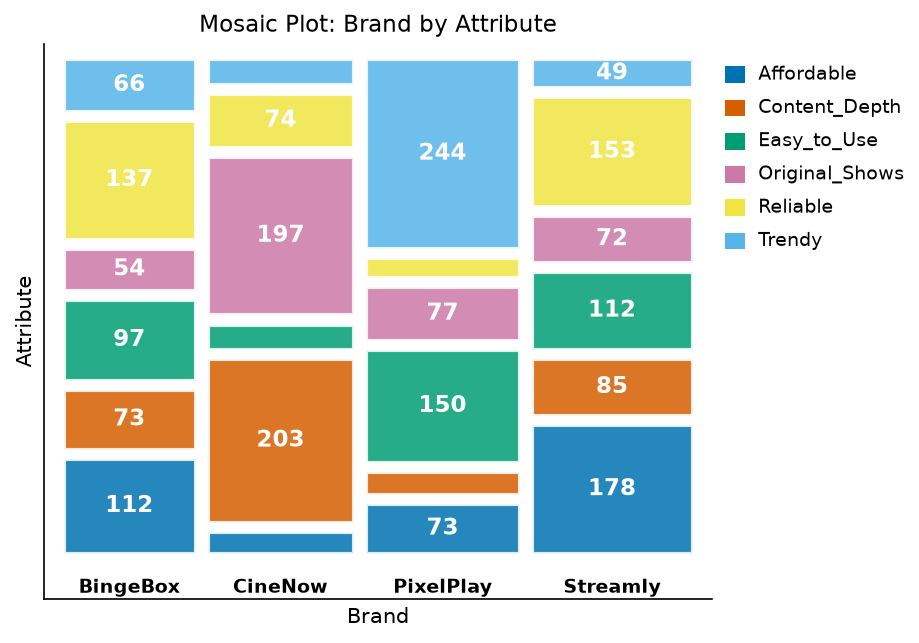

In [2]:
proc freq data=perception;
    tables Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(rename=(count=Count));
    title 'Observed Brand x Attribute Frequencies';
run;

## Step 3 — Correspondence analysis from the raw data

Now run `PROC CORRESP` directly on the respondent-level data. `TABLES Brand, Attribute;` builds the contingency table internally (brands as rows, attributes as columns).

Options used here:

- `ALL` — print the full diagnostics: observed table, profiles, expected values, and   cell chi-square contributions.
- `DIMENS=2` — compute the first two principal axes (a 2-D map).
- `OUTC=` — write row and column coordinates to a dataset for plotting.

The **inertia decomposition** tells us how much of the total association each axis explains.

In [3]:
proc corresp data=perception all dimens=2 outc=ca_coords;
    tables Brand, Attribute;
    title 'Correspondence Analysis: Streaming Brand Perception';
run;

                                         Observed Brand x Attribute Frequencies                                         

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.4479       0.2006       486.45          0.6078
          2     0.3598       0.1295       313.86          1.0000
  ---------------------------------------------------------------
  Total                      0.3301       800.31

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox            -0.0304      0.3018
  CineNow              0.6397     -0.3609
  PixelPlay           -0.6197     -0.3477
  Streamly             0.0318      0.4108

    

NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Step 4 — Read the coordinates

The `OUTC=` dataset holds the axis coordinates (`Dim1`, `Dim2`) for every brand and attribute, tagged by `_TYPE_` (`ROW` for brands, `COLUMN` for attributes). Reading them numerically alongside the inertia table confirms the structure the map will show.

From the output above:

- **Dimension 1 (60.8% of inertia)** is a *premium-content vs. trendy/casual* axis. *Content_Depth* (Dim1 = 0.5926) and *Original_Shows* (0.4406) sit at the positive end with **CineNow** (0.6397); *Trendy* (-0.7001) and *Easy_to_Use* (-0.3690) sit at the negative end with **PixelPlay** (-0.6197).
- **Dimension 2 (39.2% of inertia)** separates *Affordable* (Dim2 = 0.4738) and *Reliable* (0.4514) — pulling up **Streamly** (0.4108) and **BingeBox** (0.3018) — from *Trendy* (-0.4140) and *Original_Shows* (-0.3614), which pull down **CineNow** (-0.3609) and **PixelPlay** (-0.3477). It is a *dependable value vs. distinctive content* contrast.

In [4]:
proc print data=ca_coords noobs;
    var _TYPE_ _NAME_ Dim1 Dim2;
    title 'Row (Brand) and Column (Attribute) Coordinates';
run;

                                     Row (Brand) and Column (Attribute) Coordinates                                     

_TYPE_            _NAME_      DIM1      DIM2
ROW     BingeBox           -0.0304    0.3018
ROW     CineNow             0.6397   -0.3609
ROW     PixelPlay          -0.6197   -0.3477
ROW     Streamly            0.0318    0.4108
COLUMN  Affordable         -0.1078    0.4738
COLUMN  Content_Depth       0.5926   -0.2077
COLUMN  Easy_to_Use        -0.3690    0.0579
COLUMN  Original_Shows      0.4406   -0.3614
COLUMN  Reliable            0.1436    0.4514
COLUMN  Trendy             -0.7001   -0.4140



NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Step 5 — Project a challenger brand as a supplementary point

The analytics team has tracking data for an emerging challenger, **NovaCast**, but does not want it to distort the established perceptual map. A *supplementary* point is projected into the existing CA space **without contributing to the axis computation**.

We append a single block of six NovaCast attribute counts (a Trendy / Original-Shows leaning newcomer) to the pre-aggregated `survey_counts`, feed the frequencies with `WEIGHT Count`, and name the **level** `NovaCast` on the `SUPPLEMENTARY` statement so PROC CORRESP holds that row out of the active table. The `OBSERVED` option keeps the active contingency table (the four established brands, summing to 2400) in view — note that NovaCast does **not** appear in it, confirming it was treated as supplementary.

In [5]:
/* Append ONE clean block of NovaCast counts to the aggregated cells.
   end=last fires the block exactly once, after the last survey_counts row,
   so NovaCast contributes six rows (one per attribute) -- not a duplicated
   block. NovaCast is a Trendy / Original-Shows-led newcomer. */
data survey_counts_sup;
    set survey_counts end=last;
    output;
    if last then do;
        Brand='NovaCast'; Attribute='Trendy';          Count=10; output;
        Brand='NovaCast'; Attribute='Original_Shows';  Count=8;  output;
        Brand='NovaCast'; Attribute='Easy_to_Use';     Count=5;  output;
        Brand='NovaCast'; Attribute='Content_Depth';   Count=3;  output;
        Brand='NovaCast'; Attribute='Affordable';      Count=4;  output;
        Brand='NovaCast'; Attribute='Reliable';        Count=3;  output;
    end;
run;

proc corresp data=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    tables Brand, Attribute;
    weight Count;
    supplementary NovaCast;
    title 'Brand Perception with NovaCast as a Supplementary Point';
run;

                                     Row (Brand) and Column (Attribute) Coordinates                                     

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.4479       0.2006       486.45          0.6078
          2     0.3598       0.1295       313.86          1.0000
  ---------------------------------------------------------------
  Total                      0.3301       800.31

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox            -0.0304      0.3018
  CineNow              0.6397     -0.3609
  PixelPlay           -0.6197     -0.3477
  Streamly             0.0318      0.4108
  Nov

NOTE: DATA survey_counts_sup


NOTE: Read 24 rows from survey_counts.
NOTE: Wrote survey_counts_sup (30 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Step 6 — Draw the perceptual map

PROC CORRESP writes the symmetric row/column coordinates to the `OUTC=` dataset; we plot Dimension 2 against Dimension 1 to render the map. We tag each point by **role** — *Brand* (active rows), *Attribute* (columns), and *Challenger* (the supplementary NovaCast row) — and label every marker, so the positioning is read directly off the plot. The challenger is colored separately to underline that it was projected in, not fitted.

> **How to read a CA map.** A brand and an attribute that lie in the same direction from the origin (and far from it) are strongly associated; points near the origin are "average" and weakly differentiated. Because Dimensions 1 and 2 together capture 100% of this table's inertia, the map omits nothing.

                           Streaming-Brand Perception Map (Dim1 60.8%, Dim2 39.2% of inertia)                           



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Streaming-Brand Perception Map (Dim1 60.8%, Dim2 39.2% of inertia).
NOTE: ODS Graphics is ON (width=860px, height=600px, format=SVG).
NOTE: PROC SGPLOT data=ca_map

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


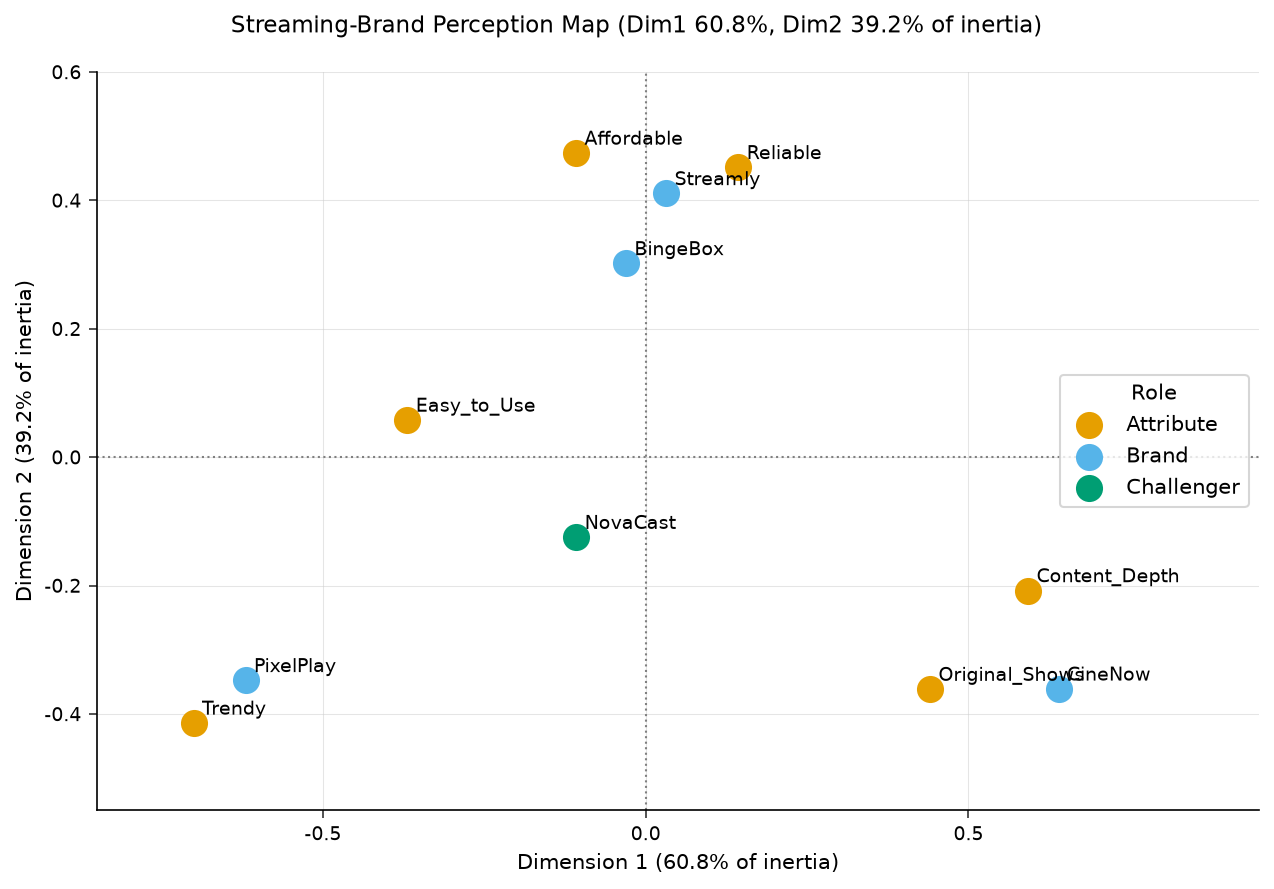

In [6]:
/* Tag each OUTC point by role for a clean, colored legend.
   Supplementary NovaCast is written to OUTC with _TYPE_='ROW',
   so we special-case it as the Challenger. */
data ca_map;
    set ca_coords_sup;
    length Role $10;
    if _NAME_ = 'NovaCast' then Role = 'Challenger';
    else if _TYPE_ = 'ROW' then Role = 'Brand';
    else Role = 'Attribute';
    keep Role _NAME_ Dim1 Dim2;
run;

title 'Streaming-Brand Perception Map (Dim1 60.8%, Dim2 39.2% of inertia)';

ods graphics on / width=860px height=600px;

/* PROC CORRESP has no native ODS map in this build, so we render the
   symmetric coordinates with PROC SGPLOT. Reference lines at 0 mark the
   origin; an explicitly padded x-range keeps the right-edge attribute
   labels (Content_Depth, CineNow) fully on the canvas, and the legend
   sits outside the plot so it never covers a point. */
proc sgplot data=ca_map;
    refline 0 / axis=x lineattrs=(color=gray pattern=dot);
    refline 0 / axis=y lineattrs=(color=gray pattern=dot);
    scatter x=Dim1 y=Dim2 / group=Role datalabel=_NAME_
                            markerattrs=(size=12 symbol=circlefilled);
    xaxis label='Dimension 1 (60.8% of inertia)' min=-0.85 max=0.95 grid;
    yaxis label='Dimension 2 (39.2% of inertia)' min=-0.55 max=0.60 grid;
    keylegend / title='Role' position=right;
run;

ods graphics off;
title;

## Interpreting the results

**The association is real and fully captured.** The chi-square test (800.31 on 15 df, p < 0.0001; Cramer's V = 0.3334) decisively rejects independence, and the two CA dimensions explain **100%** of the table's inertia (60.8% + 39.2%), so the map below is a complete summary, not a lossy projection.

**Three perceptual territories.** Reading the coordinates and the map together:

- **Premium content (right).** *CineNow* (Dim1 = 0.6397) is pulled to the right by *Content_Depth* (0.5926) and *Original_Shows* (0.4406) — it owns the depth-of-catalogue perception. Its negative Dim2 (-0.3609) sets distinctive content apart from everyday value.
- **Value & reliability (upper center).** *Streamly* (0.0318, 0.4108) and *BingeBox* (-0.0304, 0.3018) cluster with *Affordable* (-0.1078, 0.4738) and *Reliable* (0.1436, 0.4514) — the dependable, good-value pair sitting high on Dimension 2.
- **Trendy / casual (lower left).** *PixelPlay* (-0.6197, -0.3477) sits next to *Trendy* (-0.7001, -0.4140) and *Easy_to_Use* (-0.3690, 0.0579) — the youthful, of-the-moment brand.

**The supplementary challenger.** Projected without influencing the axes, **NovaCast** lands at (-0.1074, -0.1247) — close to the origin, nudged into the lower-left toward the Trendy / Easy_to_Use corner. For a media strategist that is the headline: the challenger has no distinctive equity yet and is drifting into PixelPlay's trendy/casual territory, so a differentiated positioning (rather than a me-too one) is warranted.

**Caveats.** Correspondence analysis is descriptive, not inferential — distances are approximate and axis *signs* are arbitrary (a mirror flip of either axis is the same map). With 2400 respondent-attribute associations the contingency table is well-populated (every cell is in the tens or hundreds, the smallest being CineNow x Affordable at 37), so the geometry is stable; the percentages above come straight from the inertia table, which you should always pair with the map to confirm how much association the displayed dimensions explain.